In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


from collections import namedtuple
Dataset = namedtuple('Dataset', ['X_train', 'X_test', 'y_train', 'y_test'])
Params = namedtuple('Params', ['min_samples_leaf', 'max_features', 'max_depth', 'oob_score'])
Data = namedtuple('Data', ['X','y'])
parameters = Params(3, 0.3, 25, False)


import sys
sys.path.append('../library')

import classification_rf
from importlib import reload
reload(classification_rf)

import rf_wrapper_functions as rfwrap

np.random.seed(24)

In [2]:
dataset, data = rfwrap.generate_dataset(
  n_studies = 8,
  n_datapoints_per_study = 125,
  features = 50,
  similarity = 0.75,
  intercept_sd = 1.0,
  signal_strength = 5.0,
  random_state = 0
)

parameters = Params(3, 0.3, 25, False)

norm of b: 4.0000
X shape: (125, 50)
Study 0: intercept=0.26, base_rate=0.46
X @ b range: -13.27 to 11.14
norm of b: 0.7677
X shape: (125, 50)
Study 1: intercept=-0.36, base_rate=0.39
X @ b range: -2.10 to 2.14
norm of b: 0.7002
X shape: (125, 50)
Study 2: intercept=1.45, base_rate=0.75
X @ b range: -1.77 to 1.52
norm of b: 0.8155
X shape: (125, 50)
Study 3: intercept=-0.32, base_rate=0.46
X @ b range: -2.02 to 2.86
norm of b: 0.7584
X shape: (125, 50)
Study 4: intercept=1.57, base_rate=0.78
X @ b range: -2.30 to 1.76
norm of b: 0.7755
X shape: (125, 50)
Study 5: intercept=0.13, base_rate=0.44
X @ b range: -2.26 to 1.86
norm of b: 0.7864
X shape: (125, 50)
Study 6: intercept=0.30, base_rate=0.61
X @ b range: -1.87 to 2.17
norm of b: 0.8276
X shape: (125, 50)
Study 7: intercept=1.26, base_rate=0.78
X @ b range: -2.08 to 2.37


In [3]:
accuracy_score, rf, source_score, source_size = rfwrap.forest(
    n_estimators=200, 
    dataset = dataset, 
    parameters = parameters,
    label_depth = 0,
    min_samples_label = None,
    seed = 24,
    metric = 'auc'
    )
print(accuracy_score)

0.6747246022031823


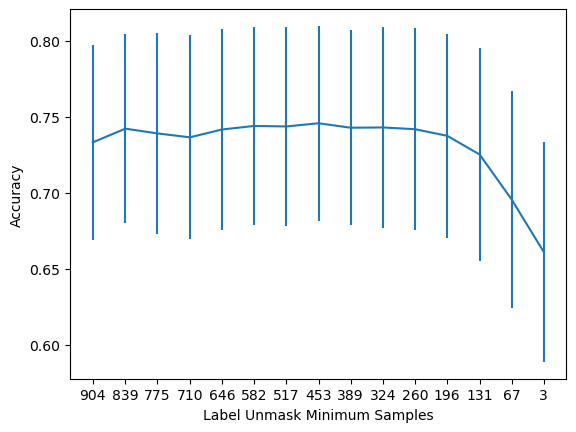

In [4]:
accuracy_score, rf, source_score, source_size, X_tests, y_tests = rfwrap.msl_errorbars_kfold_data(
    n_folds = 10,
    n_estimators=300, 
    n_forests=15,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)

arr = np.array(accuracy_score).flatten()
#print(arr)

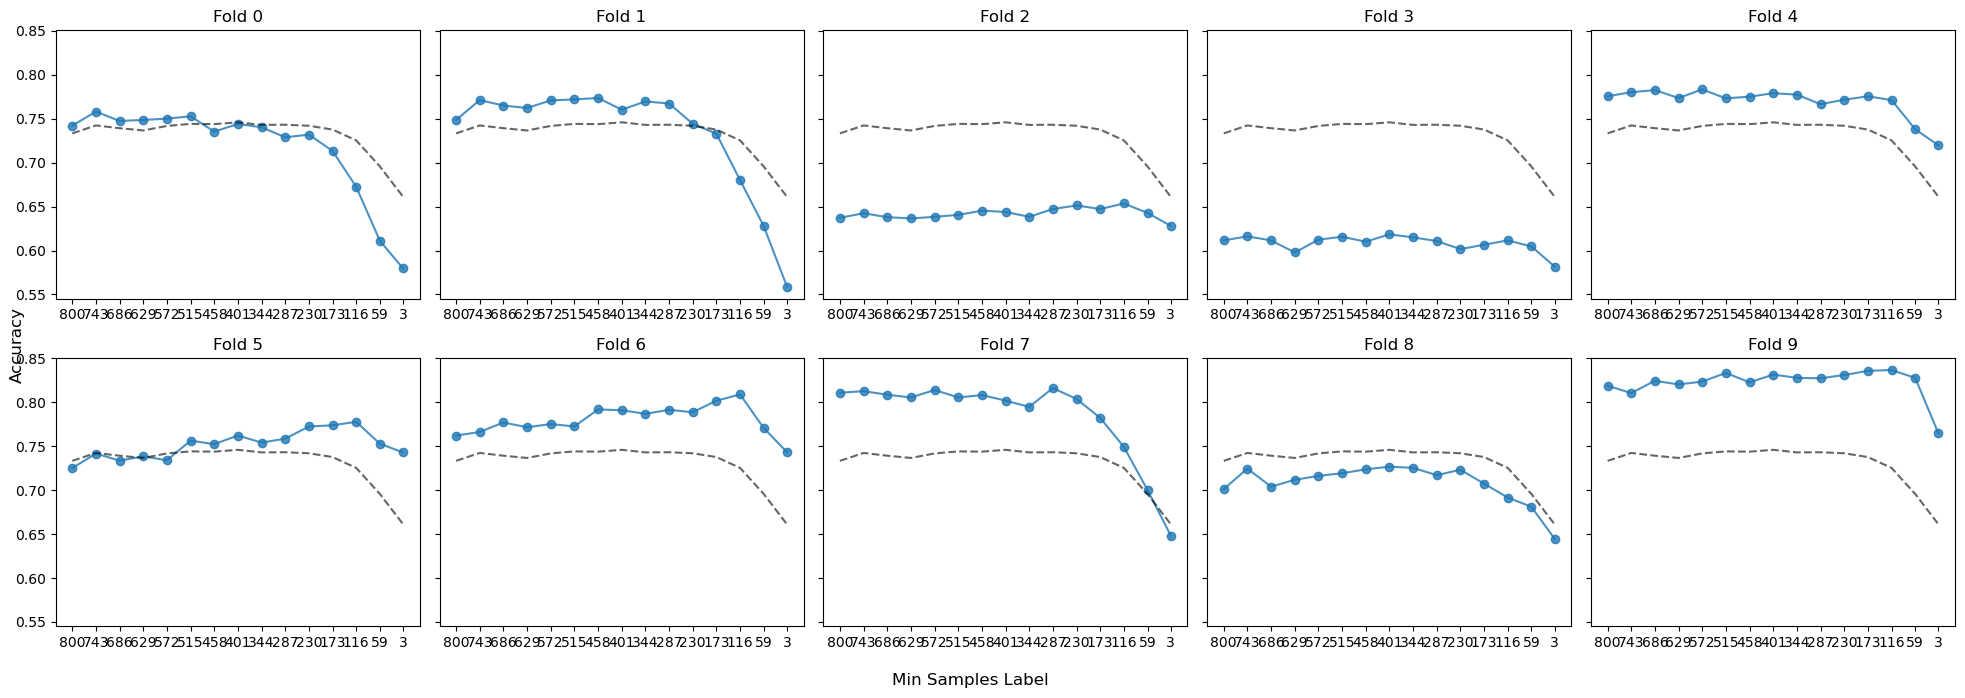

In [5]:
rfwrap.plot_forests_by_fold(accuracy_score, dataset, parameters, depth_type = "msl")

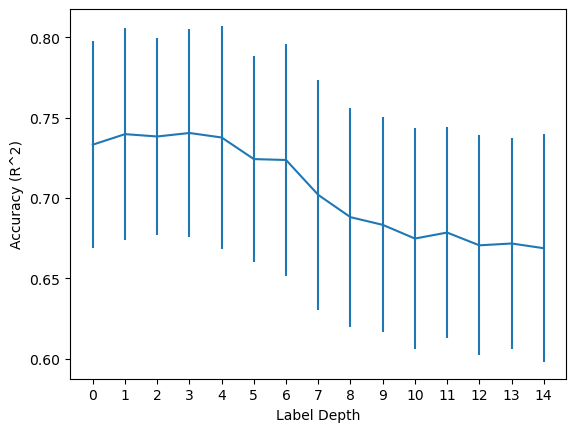

In [6]:
accuracy_score1, rf1, source_score1, source_size1, X_tests1, y_tests1 = rfwrap.errorbars_kfold_data(
    n_folds = 10,
    n_estimators=300, 
    depth=15,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)

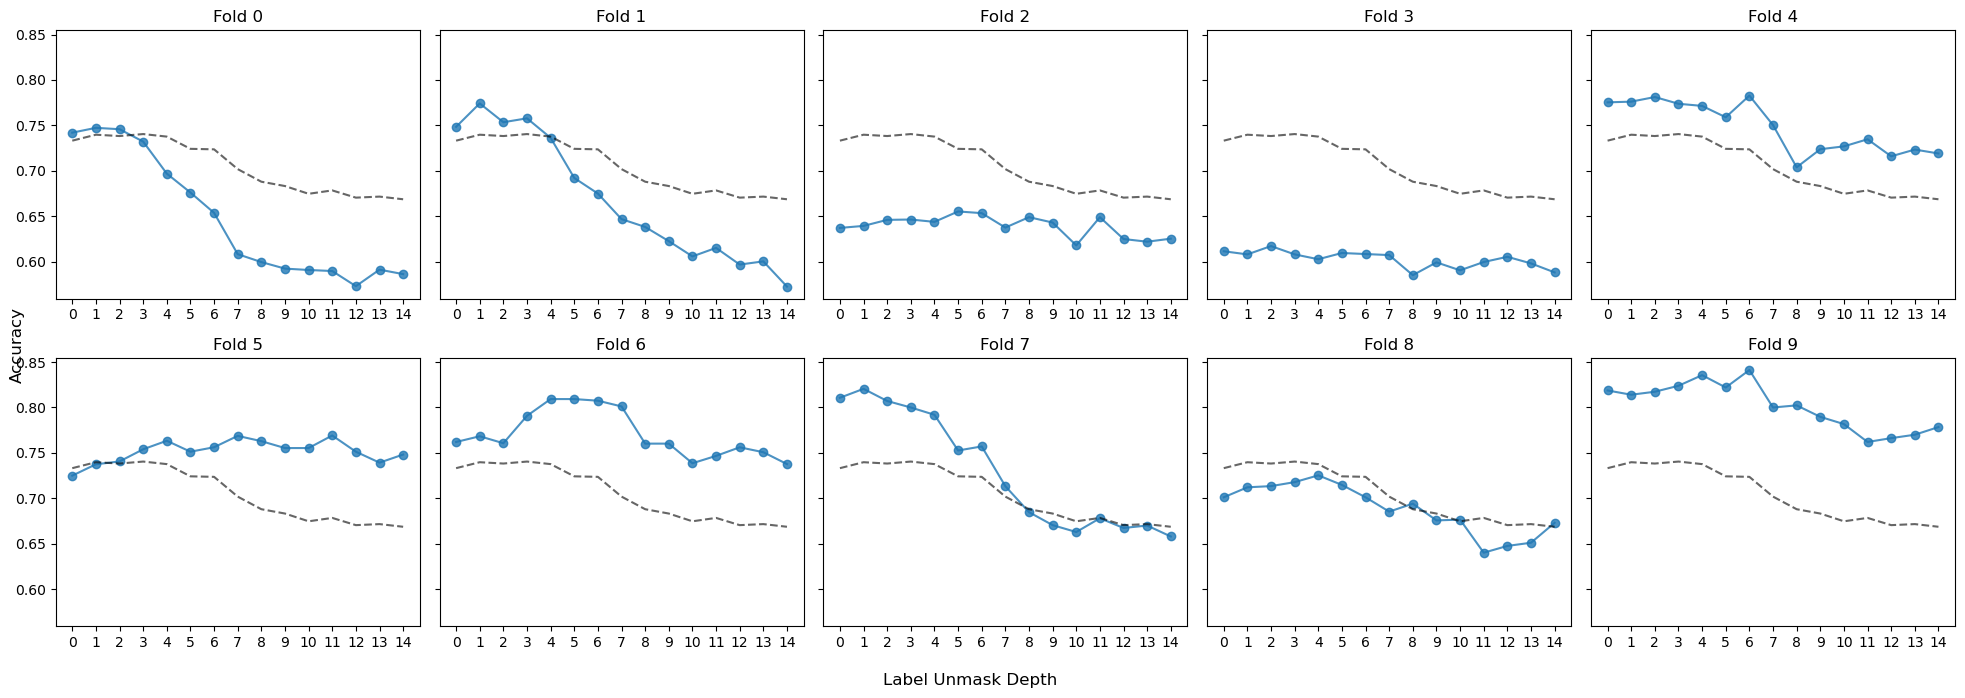

In [7]:
rfwrap.plot_forests_by_fold(accuracy_score1, dataset, parameters, depth_type = "depth")